In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve
import seaborn as sns
import random

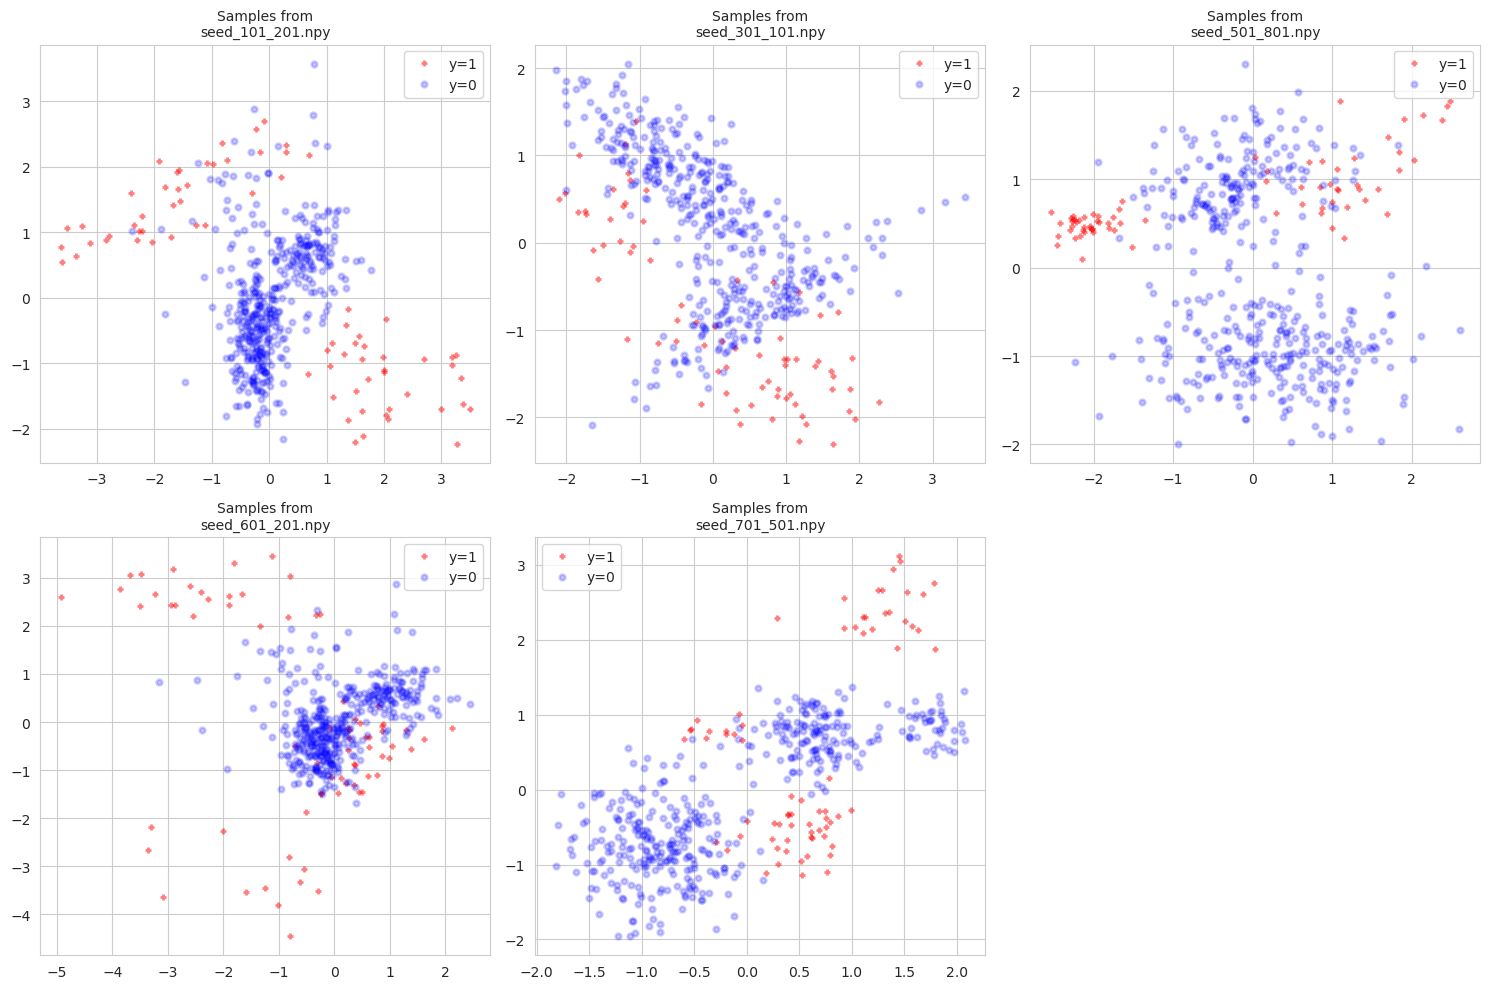

In [2]:
sns.set_style('whitegrid')

seeds = ['seed_101_201.npy', 'seed_301_101.npy', 'seed_501_801.npy', 'seed_601_201.npy', 'seed_701_501.npy']
xy500 = {}


# 1. Initialize the 2x3 grid and set overall window size
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# 2. Loop through both the data files and the grid subplots simultaneously
for seed, ax in zip(seeds, axs.flat):
    data_dict = np.load(seed, allow_pickle=True).item()

    x_N2 = data_dict['data']['x']
    y_N = data_dict['data']['y']

    random.seed(42)
    random_indices = random.sample(range(len(y_N)), 500)

    X_500 = x_N2[random_indices]
    y_500 = y_N[random_indices]
    xy500[seed] = (X_500, y_500)

    # 3. Direct the plot calls to the specific subplot 'ax'
    ax.plot(X_500[y_500 == 1, 0], X_500[y_500 == 1, 1], 'r+',
            mew=2, markersize=5, alpha=0.5, label='y=1')
    ax.plot(X_500[y_500 == 0, 0], X_500[y_500 == 0, 1], 'b.', 
            mew=2, markersize=8, alpha=0.2, label='y=0')
    
    # 4. Use ax-specific formatting methods
    ax.set_title(f"Samples from\n{seed}", fontsize=10)
    ax.legend(loc='best')

# 5. Hide the 6th subplot since you only have 5 seed files
axs.flat[-1].set_visible(False)

# 6. Prevent labels from overlapping and render the single grid figure
plt.tight_layout()
plt.show()


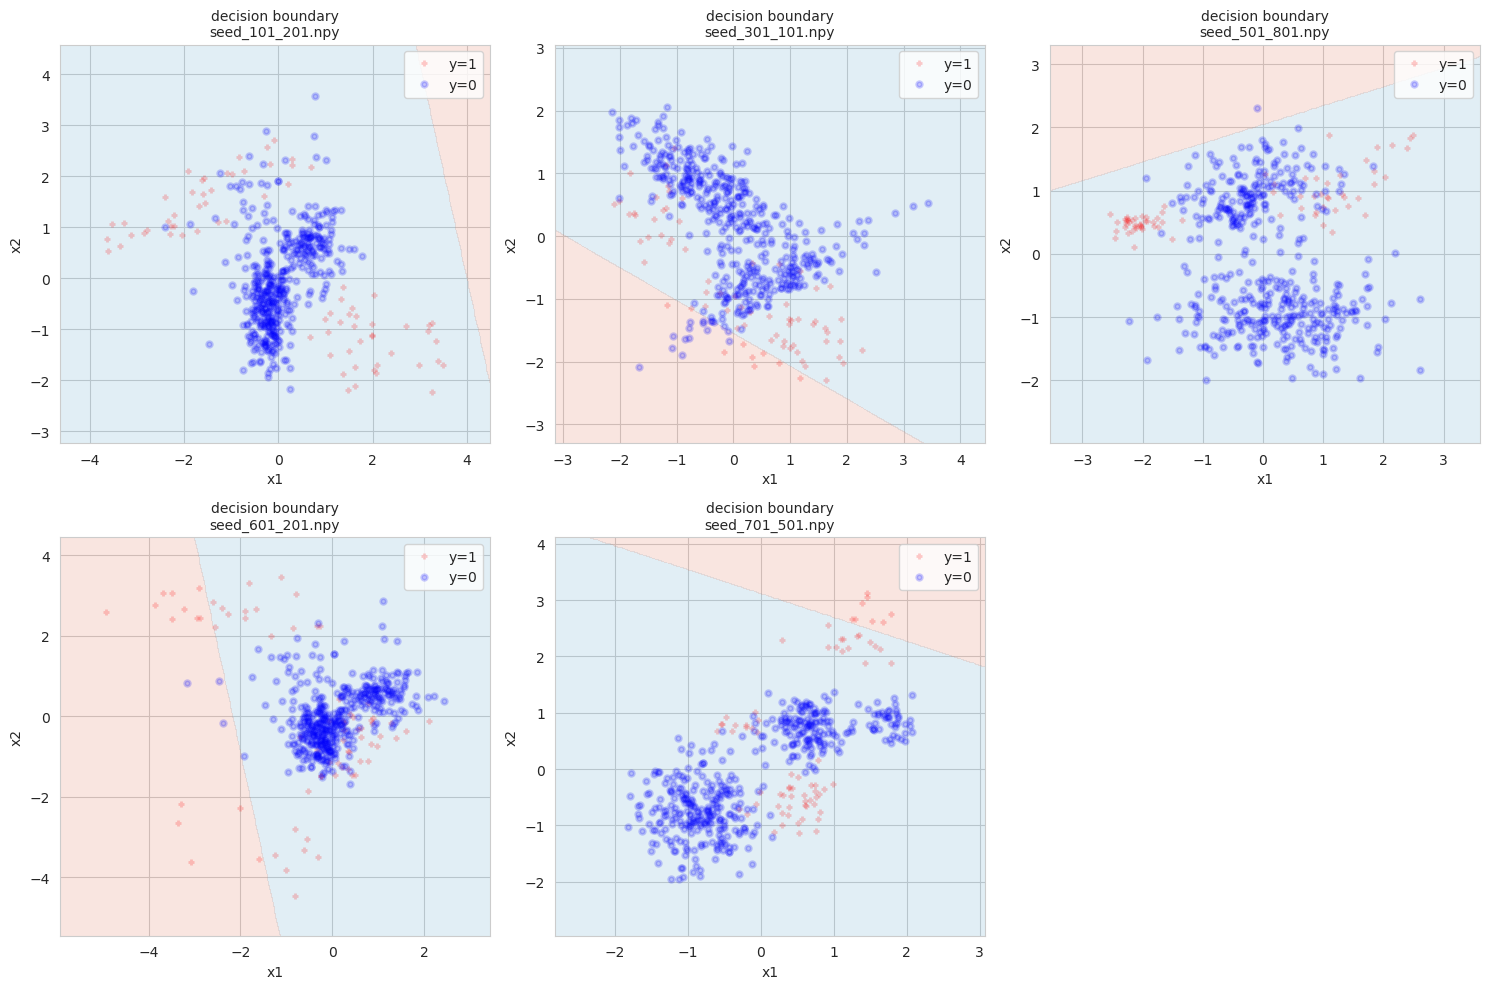

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

train_test = {}
clfs = {}

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for ax, seed in zip(axs.flat, xy500):
    X_500, y_500 = xy500[seed]
    X_train, X_test, y_train, y_test = train_test_split(
        X_500, y_500, test_size=0.3, random_state=101, stratify=y_500)

    train_test[seed] = (X_train, X_test, y_train, y_test)

    clf = LogisticRegression(solver='lbfgs', max_iter=1000)
    clf.fit(X_train, y_train)

    clfs[seed] = clf

    y_pred = clf.predict(X_test)
    # print('Test accuracy:', accuracy_score(y_test, y_pred))
    # print(classification_report(y_test, y_pred))
    # print('Confusion matrix:')
    # print(confusion_matrix(y_test, y_pred))

    xx, yy = np.meshgrid(
        np.linspace(X_500[:, 0].min() - 1, X_500[:, 0].max() + 1, 500),
        np.linspace(X_500[:, 1].min() - 1, X_500[:, 1].max() + 1, 500)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, levels=[-0.5, 0.5, 1.5], cmap='RdBu_r')
    ax.plot(X_500[y_500 == 1, 0], X_500[y_500 == 1, 1], 'r+',
            mew=2, markersize=5, alpha=0.2, label='y=1')
    ax.plot(X_500[y_500 == 0, 0], X_500[y_500 == 0, 1], 'b.',
            mew=2, markersize=8, alpha=0.2, label='y=0')
    ax.legend()
    ax.set_title(f"decision boundary\n{seed}", fontsize=10)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
import jax
import jax.numpy as jnp

In [5]:
import _geometry_jax

In [48]:
def compute_soft_roc(y_true, y_pred, thresholds, temp=0.03):
    """Computes a differentiable soft approximation of FPR and TPR."""
    y_true_col = y_true[:, None]
    y_pred_col = y_pred[:, None]
    thresh_row = thresholds[None, :]
    
    # Soft approximation of indicator I(y_pred >= threshold)
    soft_indicators = jax.nn.sigmoid((y_pred_col - thresh_row) / temp)
    
    pos_mask = y_true_col
    neg_mask = 1.0 - y_true_col
    
    soft_tps = jnp.sum(soft_indicators * pos_mask, axis=0)
    soft_fps = jnp.sum(soft_indicators * neg_mask, axis=0)
    
    P = jnp.maximum(jnp.sum(pos_mask), 1e-5)
    N = jnp.maximum(jnp.sum(neg_mask), 1e-5)
    
    return soft_fps / N, soft_tps / P

def pvoros_loss(params, X, y_true, kappa_frac, alpha, thresholds, temp=0.01):
    """Differentiable Partial VOROS loss function with a strict reality guard."""
    w, b = params

    logits = jnp.dot(X, w) + b
    y_pred = jax.nn.sigmoid(logits)

    P = jnp.sum(y_true == 1)
    N = jnp.sum(y_true == 0)

    kappa = kappa_frac*(P+N)

    # 1. Sharpen temp (e.g., 0.005 to 0.01) to eliminate soft boundary smearing
    fprs, tprs = compute_soft_roc(y_true, y_pred, thresholds, temp=temp)

    # 2. Let JAX do the filtering
    _, acc_fprs, acc_tprs, _, satisfy = _geometry_jax._kept_on_valid(
        fprs, tprs, thresholds, alpha, kappa, N, P
    )

    # 3. Calculate VOROS
    vor = _geometry_jax.voros_jax(
        acc_fprs, acc_tprs, kappa, alpha, P, N,
        1/9, 1/6, 200, False, thresholds
    )

    # --- THE REALITY GUARD ---
    # Double-check feasibility using a strict, un-smeared envelope.
    # If the model is completely outside the feasible window, force loss to 0.0.
    # This prevents geometry clipping errors from evaluating as a fake 1.0 area.
    safe_voros = jnp.where(satisfy, vor, 0.0)
    
    # Clip extreme floating-point explosions down to a valid [0, 1] range
    safe_voros = jnp.clip(safe_voros, 0.0, 1.0)

    return -safe_voros

In [49]:
from sklearn.metrics import roc_curve
import _geometry
def comparison_score(params, X, y_true, kappa_frac, alpha):
    """
    Computes the true, hard-thresholded pVOROS score using NumPy and scikit-learn.
    Optimized for evaluation loops by eliminating JAX tracing and device transfer blocks.
    """
    w, b = params
    
    # 1. Pull values off the accelerator device exactly once to avoid tracing penalties
    w_np = np.array(w)
    b_np = np.array(b)
    X_np = np.array(X)
    y_true_np = np.array(y_true)
    
    # 2. Compute predictions and true hard thresholds natively on the CPU
    logits_np = np.dot(X_np, w_np) + b_np
    y_pred_np = 1.0 / (1.0 + np.exp(-logits_np)) # Fast CPU sigmoid

    P = int(np.sum(y_true_np == 1))
    N = int(np.sum(y_true_np == 0))
    kappa = kappa_frac*(P+N)
    
    # Generate the exact, true ROC curve points (un-smoothed step functions)
    fprs, tprs, thrs = roc_curve(y_true_np, y_pred_np)
    fprs, tprs = compute_soft_roc(y_true, y_pred, thrs, temp=0.03)
    
    # 3. Filter using the original, fast NumPy geometry engine 
    # This matches your exact offline step7 validation protocol
    _, acc_fprs, acc_tprs, _, satisfy = _geometry._kept_on_valid(
        fprs, tprs, thrs, alpha, kappa, N, P
    )
    
    # 4. If the constraints aren't satisfied anywhere, return 0.0 immediately (Loss = 0.0)
    # if not satisfy:
    #     return 0.0
        
    # 5. Integrate using the true NumPy implementation
    vor = _geometry.voros(
        fprs=acc_fprs,
        tprs=acc_tprs,
        κ=kappa,
        α=alpha,
        P=P,
        N=N,
        min_fp_cost_ratio=1/9,  
        max_fp_cost_ratio=1/6,
        n_points=200,           
        thresholds=thrs  
    )

    # Return as negative to align with the JAX loss plot structure
    return -float(vor)

In [ ]:
# 1. Compile the JIT gradient function ONCE outside all loops for maximum speed
loss_grad_fn = jax.jit(jax.value_and_grad(pvoros_loss))

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

# for ax, seed in zip(axs.flat, clfs):
    # Retrieve data splits & fitted classifier parameters for this seed
seed = "seed_301_101.npy"
X_train, X_test, y_train, y_test = train_test[seed]
clf = clfs[seed]

# Extract optimal coefficients
opt_w1 = clf.coef_[0, 0]
fixed_w2 = clf.coef_[0, 1]
fixed_bias = clf.intercept_[0]

# Convert data splits to JAX arrays to avoid tracing overhead
X_test_jax = jnp.array(X_test)
y_test_jax = jnp.array(y_test)

# Set up the sweep range around the optimal w1 parameter
w1_sweep = np.linspace(opt_w1 - 4, opt_w1 + 4, 40)

pvoros_scores = []
pvoros_nongrad = []
gradients = []

kappa = 0.5
alpha = 0.6
threshold_grid = jnp.linspace(0.0, 1.0, 100)

# Run the parameter sweep using the test split
for w1 in w1_sweep:
    # 2. Format params strictly as JAX arrays
    params = (jnp.array([w1, fixed_w2], dtype=jnp.float64), jnp.array(fixed_bias, dtype=jnp.float64))

    logits = jnp.dot(X_test_jax, params[0]) + params[1]
    y_scores = jax.nn.sigmoid(logits)
    min_s, max_s = jnp.min(y_scores), jnp.max(y_scores)
    # 2. Force the JAX grid to focus purely on the active prediction area
    dynamic_grid = jnp.linspace(min_s + 1e-5, max_s - 1e-5, 100)
    
    # 3. Call the loss function with matching cost bounds (1/9 to 1/6)
    loss_val, grads = loss_grad_fn(
        params, X_test_jax, y_test_jax, kappa, alpha, dynamic_grid, temp=0.03
    )
    
    pvoros_nongrad.append(comparison_score(params, X_test_jax, y_test_jax, kappa, alpha))
    
    # 4. Append the scores (Loss is negative VOROS, so take -loss_val)
    pvoros_scores.append(float(loss_val))
    
    # 5. Extract the gradient strictly corresponding to w1 (first element of weights vector)
    gradients.append(float(grads[0][0]))
    
# --- Dual Axis Scatter Plots ---
# Left Axis: Partial VOROS
# ax.scatter(w1_sweep, pvoros_scores, color='#1f77b4', s=15, alpha=0.8, label='PVoros Score')
# ax.plot(w1_sweep, pvoros_scores, color='#1f77b4', linestyle=':', alpha=0.5)
# ax.set_ylabel('Loss(-Partial VOROS)', color='#1f77b4', fontsize=9)
# ax.tick_params(axis='y', labelcolor='#1f77b4')

# # Left Axis: Partial VOROS
# ax.scatter(w1_sweep, pvoros_nongrad, color="#961fb4", s=15, alpha=0.8, label='PVoros Score')
# ax.plot(w1_sweep, pvoros_nongrad, color="#961fb4", linestyle=':', alpha=0.5)

# # Right Axis: Gradient
# ax_grad = ax.twinx()
# ax_grad.scatter(w1_sweep, gradients, color='#d62728', s=15, alpha=0.8, label='Gradient w.r.t w1')
# ax_grad.plot(w1_sweep, gradients, color='#d62728', linestyle=':', alpha=0.5)
# ax_grad.set_ylabel(r'Loss Gradient ($\partial L / \partial w_1$)', color='#d62728', fontsize=9)
# ax_grad.tick_params(axis='y', labelcolor='#d62728')

# # Mark the optimal weight position derived from standard training
# ax.axvline(opt_w1, color='green', linestyle='--', alpha=0.7, label='Opt $w_1$ (BCE)')
# ax_grad.axhline(0, color='gray', linestyle='-', alpha=0.3)

# # Labeling
# ax.set_title(f"Parameter Sweep: {seed}\nFixed $w_2$ = {fixed_w2:.2f}", fontsize=10)
# ax.set_xlabel('Weight $w_1$')

# # Hide the unused 6th subplot
# axs.flat[-1].set_visible(False)

# plt.suptitle('Partial VOROS and Soft-Loss Gradient Over $w_1$ Sweep (Fixed $w_2$)', fontsize=14, y=0.98, fontweight='bold')
# plt.tight_layout()
# plt.show()

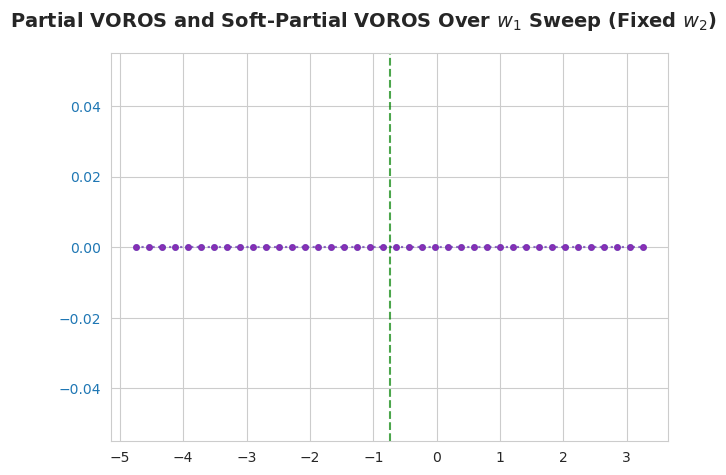

In [47]:
plt.scatter(w1_sweep, pvoros_scores, color='#1f77b4', s=15, alpha=0.8, label='PVoros Score')
plt.plot(w1_sweep, pvoros_scores, color='#1f77b4', linestyle=':', alpha=0.5)
plt.tick_params(axis='y', labelcolor='#1f77b4')

# Left Axis: Partial VOROS
plt.scatter(w1_sweep, pvoros_nongrad, color="#961fb4", s=15, alpha=0.8, label='PVoros Score')
plt.plot(w1_sweep, pvoros_nongrad, color="#961fb4", linestyle=':', alpha=0.5)

# # Right Axis: Gradient
# ax_grad = plt.twinx()
# ax_grad.scatter(w1_sweep, gradients, color='#d62728', s=15, alpha=0.8, label='Gradient w.r.t w1')
# ax_grad.plot(w1_sweep, gradients, color='#d62728', linestyle=':', alpha=0.5)
# ax_grad.set_ylabel(r'Loss Gradient ($\partial L / \partial w_1$)', color='#d62728', fontsize=9)
# ax_grad.tick_params(axis='y', labelcolor='#d62728')

# Mark the optimal weight position derived from standard training
plt.axvline(opt_w1, color='green', linestyle='--', alpha=0.7, label='Opt $w_1$ (BCE)')
# ax_grad.axhline(0, color='gray', linestyle='-', alpha=0.3)

# Labeling
# plt.set_title(f"Parameter Sweep: {seed}\nFixed $w_2$ = {fixed_w2:.2f}", fontsize=10)
# plt.set_xlabel('Weight $w_1$')

# Hide the unused 6th subplot
# axs.flat[-1].set_visible(False)

plt.suptitle('Partial VOROS and Soft-Partial VOROS Over $w_1$ Sweep (Fixed $w_2$)', fontsize=14, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()

plt.show()